Total de freelances analysés : 80
Score moyen : 72.67/100
Score médian (le milieu) : 74.35/100
Le score le plus bas est 41.4 et le plus haut est 96.1.

DÉTECTION : Aucun freelance ne présente de score statistiquement extrême.


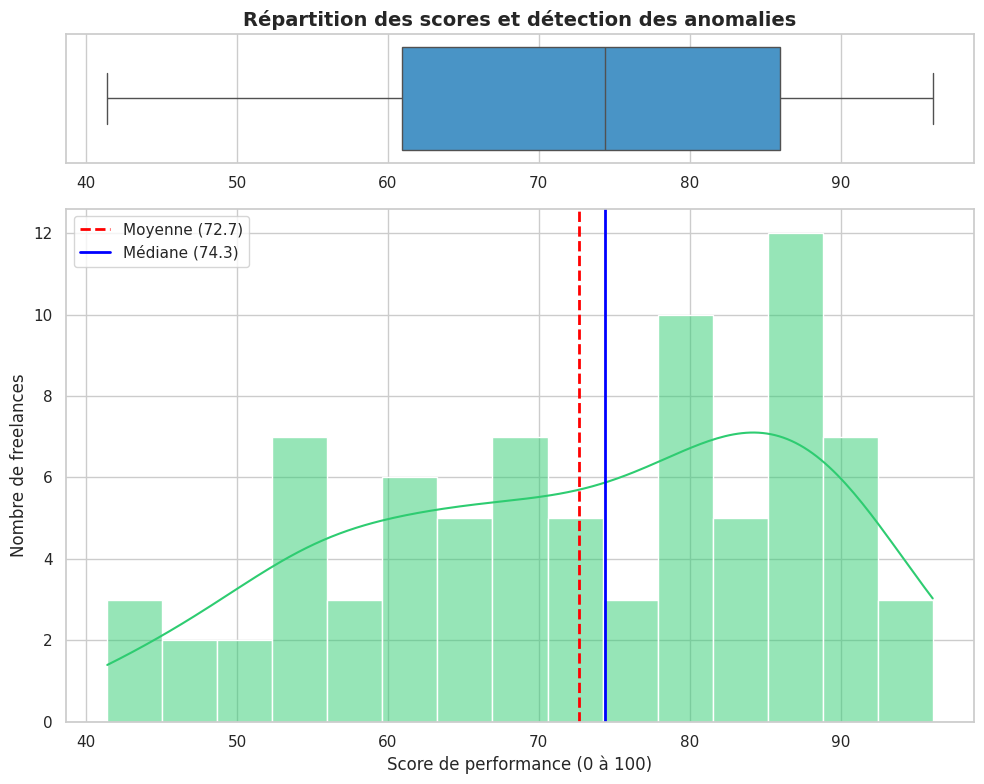

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CHARGEMENT DES DONNÉES ---
# Le fichier CSV doit être dans le même dossier que ce notebook
df = pd.read_csv("dataset_freelance_groupe.csv")


# --- 2. CALCULS STATISTIQUES (La répartition) ---
score = df["score_performance"]

moyenne = score.mean()
mediane = score.median()
ecart_type = score.std()
min_val = score.min()
max_val = score.max()

# --- 3. DÉTECTION DES CAS EXTRÊMES (Valeurs aberrantes) ---
# On utilise la méthode des quartiles (IQR) pour trouver les cas anormaux
Q1 = score.quantile(0.25)
Q3 = score.quantile(0.75)
IQR = Q3 - Q1
limite_basse = Q1 - 1.5 * IQR
limite_haute = Q3 + 1.5 * IQR

# On isole les freelances qui sont en dehors de ces limites
cas_extremes = df[(score < limite_basse) | (score > limite_haute)]

# --- 4. AFFICHAGE DES RÉSULTATS TEXTUELS ---
print(f"Total de freelances analysés : {len(score)}")
print(f"Score moyen : {moyenne:.2f}/100")
print(f"Score médian (le milieu) : {mediane:.2f}/100")
print(f"Le score le plus bas est {min_val} et le plus haut est {max_val}.\n")

if len(cas_extremes) > 0:
    print(f"DÉTECTION : Nous avons trouvé {len(cas_extremes)} freelance(s) avec des scores extrêmes :")
    print(cas_extremes[["id_freelance", "score_performance", "nombre_missions"]])
else:
    print("DÉTECTION : Aucun freelance ne présente de score statistiquement extrême.")

# --- 5. CRÉATION DES GRAPHIQUES ---
# On crée une image avec 2 graphiques (Boxplot en haut, Histogramme en bas)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [1, 4]})
sns.set_theme(style="whitegrid")

# Graphique 1 : Boxplot (Boîte à moustaches pour bien voir les extrêmes)
sns.boxplot(x=score, ax=ax_box, color="#3498db")
ax_box.set_title("Répartition des scores et détection des anomalies", fontsize=14, fontweight="bold")
ax_box.set_xlabel("") # On cache le texte de l'axe X pour faire plus propre

# Graphique 2 : Histogramme (Pour voir la forme globale)
sns.histplot(data=df, x="score_performance", ax=ax_hist, kde=True, color="#2ecc71", bins=15)
ax_hist.axvline(moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne ({moyenne:.1f})')
ax_hist.axvline(mediane, color='blue', linestyle='-', linewidth=2, label=f'Médiane ({mediane:.1f})')

ax_hist.set_xlabel("Score de performance (0 à 100)", fontsize=12)
ax_hist.set_ylabel("Nombre de freelances", fontsize=12)
ax_hist.legend()

# On affiche le tout
plt.tight_layout()
plt.show()